In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

from nexuskan import *
from nexuskan import KAN
from nexuskan import nexusKAN

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# grad test

$x_1 x_3 + x_2 x_5 + x_4$

in: 5, out: 2

In [58]:
def some_func_to_add_dim(x, out_dim):
    x_res = torch.unsqueeze(x, dim=2)
    for i in range(out_dim - 1):
        x_res = torch.concat((x_res, torch.unsqueeze(x * 2., dim=2)), dim=2)
    
    return x_res

In [59]:
batch = 4
in_dim = 5
out_dim = 2

y_true = torch.tensor([[ -6., -28.],
                       [-21., -79.],
                       [36.,  138.],
                       [11.,  42.]]) # (batch, out_dim)
criterion = nn.MSELoss()

mask = torch.tensor([[0.9, -0.5], 
                     [-0.6, 0.6], 
                     [0.8, -0.5], 
                     [-0.9, -0.6],
                     [-0.6, 0.8]]).requires_grad_(True) # (in_dim, in_dim // 2)

x = torch.tensor([[2.0, 2.0, -2.0, 2.0, -2.0],
                  [3.0, -3.0, -3.0, -3.0, 3.0],
                  [4.0, -4.0, 4.0, 4.0, -4.0],
                  [4.0, -1.0, 2.0, 1.0, -2.0]]).requires_grad_(True) # (batch, in_dim)

y = some_func_to_add_dim(x, out_dim=out_dim) # (batch, in_dim, out_dim)

tau = 0.1
hard_mask = torch.sigmoid(mask / tau) # (in_dim, in_dim // 2)

# --- signs with threshold ---
# epsilon = 1e-8
# sign_data = torch.sign(y + epsilon) # (batch, in_dim, out_dim)
# mask_expanded = hard_mask[None, :, None, :] # (1, in_dim, 1, groups)
# sign_data_expanded = sign_data.unsqueeze(-1) # (batch, in_dim, out_dim, 1)
# selected_signs = torch.where(mask_expanded > 0.5, sign_data_expanded, 1.0) # (batch, in_dim, out_dim, in_dim // 2)
# final_sign = torch.prod(selected_signs, dim=1) # (batch, out_dim, in_dim // 2)
# masked_y_for_prod = torch.pow(torch.abs(y.unsqueeze(-1)), hard_mask[None, :, None, :]) # (batch, in_dim, out_dim, in_dim // 2)

# --- signs with linear representation ---
masked_y_for_prod = 1 - hard_mask[None, :, None, :] + hard_mask[None, :, None, :] * y.unsqueeze(-1) # (batch, in_dim, out_dim, in_dim // 2)
y_prod = torch.prod(masked_y_for_prod, dim=1) # (batch, out_dim, in_dim // 2)

masked_y_for_sum = y * (1. - torch.sum(hard_mask, dim=1)[:, None]) # (batch, in_dim, out_dim)

y = torch.sum(masked_y_for_sum, dim=1) + torch.sum(y_prod, dim=2)

print("y.size() =", y.size())
print(y)
loss = criterion(y, y_true)
loss.backward()
print(mask.grad)



y.size() = torch.Size([4, 2])
tensor([[ -5.9285, -27.7758],
        [-20.7027, -76.5018],
        [ 36.2673, 140.2303],
        [ 10.9046,  41.8166]], grad_fn=<AddBackward0>)
tensor([[ 1.2219e-03,  9.8583e+00],
        [-3.6339e+00,  6.6149e-01],
        [ 3.4755e-03,  2.8841e+01],
        [ 4.8847e-01,  1.0591e+01],
        [-1.0303e+01,  8.8898e-02]])


# **Dataset** $y = x_0 x_2 +  x_4 \sin{2 \pi x_3} + x_2$ and 2 learnable prod group

In [3]:
end_range = 1.0
start_range = -1.0
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 5) + start_range
y = x[:, 0] * x[:, 2] + torch.sin(2 * torch.pi * x[:, 3]) * x[:, 4] + x[:, 1]
dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
  
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 5]), torch.Size([1000, 1]))

In [14]:
def get_tau(step, total_steps, tau_start=5.0, tau_end=0.5):
    return tau_start * (tau_end / tau_start) ** (step / total_steps)

def get_lr(epoch, epochs, lr_start=1e-1, lr_end=1e-2):
    return lr_start * (lr_end / lr_start) ** (epoch / epochs)

def get_lamb(epoch, epochs, lamb_start=1e-1, lamb_end=1e-2):
    return lamb_start * (lamb_end / lamb_start) ** (epoch / epochs)

def fit_model(model, dataset, lr=0.1, batch_size=512, epochs=1000):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    # Коэффициенты регуляризации
    lamb_l1_acts = 1e-6  # для L1 активаций 1.
    lamb_ent_acts = 1e-3  # для энтропии активаций 2.

    for epoch in range(epochs):
        batches = dataset['train_input'].shape[0] // batch_size
        for batch_idx in range(batches):
            start = batch_idx * batch_size
            end = start + batch_size if batch_idx != batches - 1 else dataset['train_input'].shape[0]
            indices = torch.arange(start, end)
            batch_x = dataset['train_input'][indices]
            batch_y = dataset['train_label'][indices]
            
            for param_group in optimizer.param_groups:
                param_group['lr'] = get_lr(epoch, epochs, lr_start=lr, lr_end=1e-2)
                    
            new_tau = get_tau(epoch, epochs, tau_start=1.0, tau_end=0.1)
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    module.tau = new_tau
                    
            # if epoch % 1000 == 0:
            #     model.update_grid(batch_x)

            outputs = model(batch_x)
            train_loss = criterion(outputs, batch_y)
            
            # --- Энтропийная регуляризация вероятностей операций ---
            lamb_ent_ops = get_lamb(epoch, epochs, lamb_start=1e-2, lamb_end=1.0)
            
            entropy_ops = 0.0
            num_layers_ops = 0
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    probs = torch.softmax(module.logits / module.tau, dim=-1)  # (in_dim, out_dim, groups+1)
                    eps = 1e-8
                    entropy_i = -torch.sum(probs * torch.log(probs + eps), dim=-1)  # (in_dim, out_dim)
                    entropy_ops += entropy_i.mean()
                    num_layers_ops += 1
            entropy_ops_avg = entropy_ops / num_layers_ops if num_layers_ops > 0 else 0.0
            
            # --- Регуляризация активаций (L1 и энтропия) ---
            l1_acts = 0.0
            entropy_acts = 0.0
            num_layers_acts = 0
            for acts in model.acts_scale_spline:
                l1_acts += torch.sum(acts)
                # Энтропия по строкам и столбцам
                p_row = acts / (torch.sum(acts, dim=1, keepdim=True) + 1e-8)
                p_col = acts / (torch.sum(acts, dim=0, keepdim=True) + 1e-8)
                entropy_row = -torch.mean(torch.sum(p_row * torch.log2(p_row + 1e-8), dim=1))
                entropy_col = -torch.mean(torch.sum(p_col * torch.log2(p_col + 1e-8), dim=0))
                entropy_acts += entropy_row + entropy_col
                num_layers_acts += 1
            l1_acts_avg = l1_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            entropy_acts_avg = entropy_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            
            loss = train_loss + lamb_ent_ops * entropy_ops_avg + lamb_l1_acts * l1_acts_avg + lamb_ent_acts * entropy_acts_avg
            # loss = train_loss + lamb_l1_acts * l1_acts_avg + lamb_ent_acts * entropy_acts_avg
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        with torch.no_grad():
            test_outputs = model(dataset['test_input'])
            test_loss = criterion(test_outputs, dataset['test_label'])
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}')#, reg: {l1_reg:.4f}')
            # for module in model.modules():
            #     if isinstance(module, NexusKANLayer):
            #         probs = torch.softmax(module.logits / module.tau, dim=-1)
            #         rounded_probs = probs.round(decimals=3)
            #         print(rounded_probs)
        

checkpoint directory created: ./model
saving model version 0.0


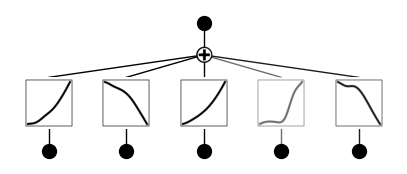

In [15]:
model = nexusKAN(width=[5, 1], grid=5, k=3, seed=42, device=device)
model(dataset['train_input'])
model.plot()

In [16]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=512, 
          epochs=1000)

Epoch [10/1000], Train Loss: 0.3204, Test Loss: 0.3072
Epoch [20/1000], Train Loss: 0.2687, Test Loss: 0.2942
Epoch [30/1000], Train Loss: 0.2630, Test Loss: 0.2901
Epoch [40/1000], Train Loss: 0.2613, Test Loss: 0.2828
Epoch [50/1000], Train Loss: 0.2593, Test Loss: 0.2842
Epoch [60/1000], Train Loss: 0.2577, Test Loss: 0.2832
Epoch [70/1000], Train Loss: 0.2570, Test Loss: 0.2843
Epoch [80/1000], Train Loss: 0.2561, Test Loss: 0.2859
Epoch [90/1000], Train Loss: 0.2527, Test Loss: 0.2832
Epoch [100/1000], Train Loss: 0.1903, Test Loss: 0.2141
Epoch [110/1000], Train Loss: 0.1513, Test Loss: 0.1776
Epoch [120/1000], Train Loss: 0.0637, Test Loss: 0.0509
Epoch [130/1000], Train Loss: 0.0099, Test Loss: 0.0110
Epoch [140/1000], Train Loss: 0.0038, Test Loss: 0.0046
Epoch [150/1000], Train Loss: 0.0032, Test Loss: 0.0035
Epoch [160/1000], Train Loss: 0.0022, Test Loss: 0.0029
Epoch [170/1000], Train Loss: 0.0020, Test Loss: 0.0026
Epoch [180/1000], Train Loss: 0.0017, Test Loss: 0.0022
E

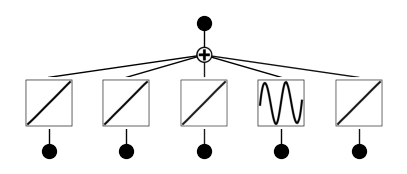

In [17]:
model.plot()

In [8]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data)

act_fun.0.coef tensor([[[-2.5917e+00, -1.7077e+00, -9.2896e-01, -2.2193e-01,  2.2945e-01,
           5.3958e-01,  6.8732e-01,  5.9573e-01]],

        [[-2.3639e+00, -1.5902e+00, -8.2842e-01, -2.3877e-01,  2.4050e-01,
           5.6155e-01,  8.0915e-01,  5.6565e-01]],

        [[-2.0930e+00, -1.4641e+00, -5.8742e-01, -8.9697e-02,  1.0368e-01,
          -2.9131e-02, -4.8604e-01, -1.3396e+00]],

        [[-9.0715e+00,  1.5899e+00,  1.3431e+00, -2.9711e+00,  2.9794e+00,
          -1.3395e+00, -1.4921e+00,  8.9133e+00]],

        [[-1.4273e+00, -7.1194e-01, -3.3075e-01, -3.4120e-02,  5.1406e-02,
          -4.5724e-03, -2.2393e-01, -5.8581e-01]]], device='cuda:0')
act_fun.0.scale_base tensor([[ 2.1000],
        [ 0.8670],
        [ 0.7834],
        [-0.5675],
        [ 0.3182]], device='cuda:0')
act_fun.0.scale_sp tensor([[0.8763],
        [0.4813],
        [0.1834],
        [3.9227],
        [0.1428]], device='cuda:0')
act_fun.0.logits tensor([[[-0.2714,  4.6683, -0.8546]],

        [[-1.09

In [18]:
for module in model.modules():
    if isinstance(module, NexusKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[0., 1., 0.]],

        [[0., 0., 1.]],

        [[0., 1., 0.]],

        [[1., 0., 0.]],

        [[1., 0., 0.]]], device='cuda:0', grad_fn=<RoundBackward1>)


# **Dataset** $y = \frac{\frac{x_0}{x_1} + \frac{x_2}{x_3}}{\frac{x_4}{x_5} + \frac{x_6}{x_7}}$ 

## LBFGS

In [343]:
def get_tau(step, total_steps, tau_start=5.0, tau_end=0.5):
    return tau_start * (tau_end / tau_start) ** (step / total_steps)

def get_lr(epoch, epochs, lr_start=1e-1, lr_end=1e-2):
    return lr_start * (lr_end / lr_start) ** (epoch / epochs)

def get_lamb(epoch, epochs, lamb_start=1e-1, lamb_end=1e-2):
    return lamb_start * (lamb_end / lamb_start) ** (epoch / epochs)

def fit_model(model, dataset, lr=0.1, epochs=1000, 
                    logits_requires_grad=True, splines_requires_grad=True,
                    use_full_batch=True, batch_size=512):
    """
    Обучение модели с оптимизатором LBFGS.
    
    Args:
        use_full_batch: если True — используется весь датасет за шаг (рекомендуется для LBFGS)
                        если False — эмуляция mini-batch (менее стабильно)
    """
    # Инициализация LBFGS
    optimizer = optim.LBFGS(model.parameters(), 
                           lr=lr, 
                           history_size=10, 
                           line_search_fn="strong_wolfe", 
                           tolerance_grad=1e-32, 
                           tolerance_change=1e-32)
    criterion = nn.MSELoss()
    
    lamb_l1_acts = 1e-3
    lamb_ent_acts = 1e-3

    for epoch in range(epochs):
        # === Обновление гиперпараметров (раз в эпоху, не внутри closure!) ===
        current_lr = lr
        # current_lr = get_lr(epoch, epochs, lr_start=lr, lr_end=1e-2)
        new_tau = get_tau(epoch, epochs, tau_start=2.0, tau_end=0.1)
        
        # Обновление requires_grad и tau для слоёв модели
        for module in model.modules():
            if isinstance(module, NexusKANLayer):
                module.logits.requires_grad = logits_requires_grad
                module.scale_base.requires_grad = splines_requires_grad
                module.scale_sp.requires_grad = splines_requires_grad
                module.coef.requires_grad = splines_requires_grad
                module.tau = new_tau
        
        # Обновление learning rate в оптимизаторе
        for param_group in optimizer.param_groups:
            param_group['lr'] = current_lr
        
        # === Функция closure для LBFGS ===
        def closure():
            optimizer.zero_grad()
            
            if use_full_batch:
                # Полный датасет (рекомендуется)
                batch_x = dataset['train_input']
                batch_y = dataset['train_label']
            else:
                # Эмуляция mini-batch (не рекомендуется для LBFGS)
                idx = torch.randperm(dataset['train_input'].shape[0])[:batch_size]
                batch_x = dataset['train_input'][idx]
                batch_y = dataset['train_label'][idx]
            
            outputs = model(batch_x)
            train_loss = criterion(outputs, batch_y)
            
            # --- Энтропийная регуляризация вероятностей операций ---
            # lamb_ent_ops = 10.0
            lamb_ent_ops = get_lamb(epoch, epochs, lamb_start=1e-2, lamb_end=10.0)
            
            entropy_ops = 0.0
            num_layers_ops = 0
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    probs = torch.softmax(module.logits / module.tau, dim=-1)  # (in_dim, out_dim, groups+1)
                    eps = 1e-8
                    entropy_i = -torch.sum(probs * torch.log(probs + eps), dim=-1)  # (in_dim, out_dim)
                    entropy_ops += entropy_i.mean()
                    num_layers_ops += 1
            entropy_ops_avg = entropy_ops / num_layers_ops if num_layers_ops > 0 else 0.0
            
            # === Регуляризация активаций (L1 + энтропия) ===
            l1_acts = 0.0
            entropy_acts = 0.0
            num_layers_acts = 0
            for acts in model.acts_scale_spline:
                l1_acts += torch.sum(acts)
                p_row = acts / (torch.sum(acts, dim=1, keepdim=True) + 1e-8)
                p_col = acts / (torch.sum(acts, dim=0, keepdim=True) + 1e-8)
                entropy_row = -torch.mean(torch.sum(p_row * torch.log2(p_row + 1e-8), dim=1))
                entropy_col = -torch.mean(torch.sum(p_col * torch.log2(p_col + 1e-8), dim=0))
                entropy_acts += entropy_row + entropy_col
                num_layers_acts += 1
            
            l1_acts_avg = l1_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            entropy_acts_avg = entropy_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            
            # loss = train_loss + lamb_l1_acts * l1_acts_avg + lamb_ent_acts * entropy_acts_avg
            loss = train_loss + lamb_ent_ops * entropy_ops_avg + lamb_l1_acts * l1_acts_avg + lamb_ent_acts * entropy_acts_avg
            
            loss.backward()
            return loss
        
        # === Шаг оптимизации ===
        optimizer.step(closure)
        
        # === Оценка на тесте ===
        with torch.no_grad():
            train_out = model(dataset['train_input'])
            train_loss = criterion(train_out, dataset['train_label'])
            test_out = model(dataset['test_input'])
            test_loss = criterion(test_out, dataset['test_label'])
        
        if (epoch + 1) % 10 == 0:
            print(f'--- Epoch [{epoch+1}/{epochs}], '
                  f'Train Loss: {train_loss.item():.4f}, '
                  f'Test Loss: {test_loss.item():.4f}')

## Adam

In [40]:
def get_tau(step, total_steps, tau_start=5.0, tau_end=0.5):
    return tau_start * (tau_end / tau_start) ** (step / total_steps)

def get_tau_osc(step, total_steps, tau_start=2.0, tau_sup=1.0, tau_end=0.1, freq=7.0):
    top_th = tau_start * (tau_end / tau_start) ** (step / total_steps)
    bottom_th = tau_sup * (tau_end / tau_sup) ** (step / total_steps)
    osc = (top_th + bottom_th) + (top_th - bottom_th) * np.cos(freq * torch.pi * step / total_steps)
    return osc / 2

def get_lr(epoch, epochs, lr_start=1e-1, lr_end=1e-2):
    return lr_start * (lr_end / lr_start) ** (epoch / epochs)

def get_lamb(epoch, epochs, lamb_start=1e-1, lamb_end=1e-2):
    return lamb_start * (lamb_end / lamb_start) ** (epoch / epochs)

# def get_lamb_osc(step, total_steps, tau_start=2.0, tau_sup=1.0, tau_end=0.1, freq=3.0):
#     top_th = tau_start * (tau_end / tau_start) ** (step / total_steps)
#     bottom_th = tau_sup * (tau_end / tau_sup) ** (step / total_steps)
#     osc = (top_th + bottom_th) - (top_th - bottom_th) * np.cos(freq * torch.pi * step / total_steps)
#     return osc / 2

def fit_model(model, dataset, lr=0.1, batch_size=512, epochs=1000, logits_requires_grad=True, splines_requires_grad=True):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    # Коэффициенты регуляризации
    lamb_l1_acts = 1e-3  # для L1 активаций 1.
    lamb_ent_acts = 1e-3  # для энтропии активаций 2.

    for epoch in range(epochs):
        batches = dataset['train_input'].shape[0] // batch_size
        for batch_idx in range(batches):
            start = batch_idx * batch_size
            end = start + batch_size if batch_idx != batches - 1 else dataset['train_input'].shape[0]
            indices = torch.arange(start, end)
            batch_x = dataset['train_input'][indices]
            batch_y = dataset['train_label'][indices]
            
            for param_group in optimizer.param_groups:
                param_group['lr'] = get_lr(epoch, epochs, lr_start=lr, lr_end=1e-2)
            
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    module.logits.requires_grad = logits_requires_grad
                    
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    module.scale_base.requires_grad = splines_requires_grad
                    module.scale_sp.requires_grad = splines_requires_grad
                    module.coef.requires_grad = splines_requires_grad
                   
            # new_tau = 2.0 
            new_tau = get_tau(epoch, epochs, tau_start=2.0, tau_end=0.1)
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    module.tau = new_tau
                    
            # if epoch % 1000 == 0:
            #     model.update_grid(batch_x)

            outputs = model(batch_x)
            train_loss = criterion(outputs, batch_y)
            
            # --- Энтропийная регуляризация вероятностей операций ---
            # lamb_ent_ops = 10.0
            lamb_ent_ops = get_lamb(epoch, epochs, lamb_start=1e-2, lamb_end=10.0)
            
            entropy_ops = 0.0
            num_layers_ops = 0
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    probs = torch.softmax(module.logits / module.tau, dim=-1)  # (in_dim, out_dim, groups+1)
                    eps = 1e-8
                    entropy_i = -torch.sum(probs * torch.log(probs + eps), dim=-1)  # (in_dim, out_dim)
                    entropy_ops += entropy_i.mean()
                    num_layers_ops += 1
            entropy_ops_avg = entropy_ops / num_layers_ops if num_layers_ops > 0 else 0.0
            
            # --- Регуляризация активаций (L1 и энтропия) ---
            l1_acts = 0.0
            entropy_acts = 0.0
            num_layers_acts = 0
            for acts in model.acts_scale_spline:
                l1_acts += torch.sum(acts)
                # Энтропия по строкам и столбцам
                p_row = acts / (torch.sum(acts, dim=1, keepdim=True) + 1e-8)
                p_col = acts / (torch.sum(acts, dim=0, keepdim=True) + 1e-8)
                entropy_row = -torch.mean(torch.sum(p_row * torch.log2(p_row + 1e-8), dim=1))
                entropy_col = -torch.mean(torch.sum(p_col * torch.log2(p_col + 1e-8), dim=0))
                entropy_acts += entropy_row + entropy_col
                num_layers_acts += 1
            l1_acts_avg = l1_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            entropy_acts_avg = entropy_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            
            # loss = train_loss + lamb_ent_ops * entropy_ops_avg + lamb_l1_acts * l1_acts_avg + lamb_ent_acts * entropy_acts_avg
            loss = train_loss + lamb_l1_acts * l1_acts_avg + lamb_ent_acts * entropy_acts_avg
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        with torch.no_grad():
            test_outputs = model(dataset['test_input'])
            test_loss = criterion(test_outputs, dataset['test_label'])
        
        if (epoch + 1) % 10 == 0:
            print(f'--- Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}')#, reg: {l1_reg:.4f}')
            # for module in model.modules():
            #     if isinstance(module, NexusKANLayer):
            #         probs = torch.softmax(module.logits / module.tau, dim=-1)
            #         rounded_probs = probs.round(decimals=3)
            #         print("tau: ", module.tau)
            #         print(rounded_probs)

## **Test 1 :** $y = \frac{x_0}{x_1} + \frac{x_2}{x_3}$

In [263]:
end_range = 1.0
start_range = 0.1
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 4) + start_range

y = x[:, 0] / x[:, 1] + x[:, 2] / x[:, 3]

dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 4]), torch.Size([1000, 1]))

checkpoint directory created: ./model
saving model version 0.0


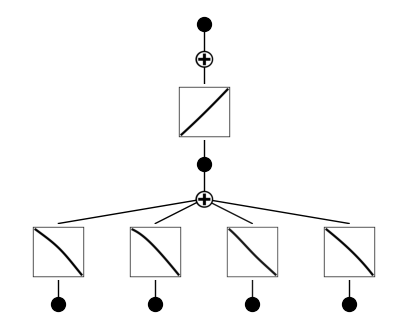

In [264]:
model = nexusKAN(width=[4, 1, 1], grid=5, k=3, seed=42, 
                #  grid_range=[0.5, 4.0], 
                 device=device)
model(dataset['train_input'])
model.plot()

In [265]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=512, 
          epochs=1000)

--- Epoch [10/1000], Train Loss: 3.3986, Test Loss: 3.1160
--- Epoch [20/1000], Train Loss: 1.4302, Test Loss: 1.6826
--- Epoch [30/1000], Train Loss: 0.8661, Test Loss: 1.1503
--- Epoch [40/1000], Train Loss: 0.5979, Test Loss: 0.9131
--- Epoch [50/1000], Train Loss: 0.5040, Test Loss: 0.7140
--- Epoch [60/1000], Train Loss: 0.4528, Test Loss: 0.6208
--- Epoch [70/1000], Train Loss: 0.4064, Test Loss: 0.5769
--- Epoch [80/1000], Train Loss: 0.3788, Test Loss: 0.5435
--- Epoch [90/1000], Train Loss: 0.3520, Test Loss: 0.5052
--- Epoch [100/1000], Train Loss: 0.3278, Test Loss: 0.4694
--- Epoch [110/1000], Train Loss: 0.3052, Test Loss: 0.4355
--- Epoch [120/1000], Train Loss: 0.2838, Test Loss: 0.4018
--- Epoch [130/1000], Train Loss: 0.2626, Test Loss: 0.3667
--- Epoch [140/1000], Train Loss: 0.2408, Test Loss: 0.3296
--- Epoch [150/1000], Train Loss: 0.2186, Test Loss: 0.2918
--- Epoch [160/1000], Train Loss: 0.1978, Test Loss: 0.2559
--- Epoch [170/1000], Train Loss: 0.1811, Test Lo

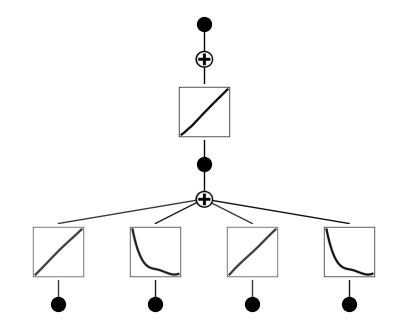

In [266]:
model.plot()

In [267]:
for module in model.modules():
    if isinstance(module, NexusKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[0.0010, 0.9540, 0.0450]],

        [[0.0010, 0.9150, 0.0840]],

        [[0.9740, 0.0020, 0.0240]],

        [[0.9110, 0.0020, 0.0870]]], device='cuda:0', grad_fn=<RoundBackward1>)
tensor([[[1.]]], device='cuda:0', grad_fn=<RoundBackward1>)


## **Test 2 :** $y = \frac{x_0}{x_1}$

In [380]:
end_range = 1.0
start_range = 0.1
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 2) + start_range
# x[:, 1] = 0.5

y = x[:, 0] / x[:, 1]

dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 2]), torch.Size([1000, 1]))

In [381]:
model = nexusKAN(width=[2, 1, 1], grid=5, k=3, seed=42, 
                #  grid_range=[0.5, 4.0], 
                 device=device)

checkpoint directory created: ./model
saving model version 0.0


In [382]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=512, 
          epochs=1000)

--- Epoch [10/1000], Train Loss: 1.6515, Test Loss: 1.3138
--- Epoch [20/1000], Train Loss: 1.0971, Test Loss: 0.8116
--- Epoch [30/1000], Train Loss: 0.5054, Test Loss: 0.2987
--- Epoch [40/1000], Train Loss: 0.2405, Test Loss: 0.1266
--- Epoch [50/1000], Train Loss: 0.1234, Test Loss: 0.0638
--- Epoch [60/1000], Train Loss: 0.0554, Test Loss: 0.0256
--- Epoch [70/1000], Train Loss: 0.0310, Test Loss: 0.0152
--- Epoch [80/1000], Train Loss: 0.0228, Test Loss: 0.0112
--- Epoch [90/1000], Train Loss: 0.0183, Test Loss: 0.0098
--- Epoch [100/1000], Train Loss: 0.0155, Test Loss: 0.0084
--- Epoch [110/1000], Train Loss: 0.0133, Test Loss: 0.0069
--- Epoch [120/1000], Train Loss: 0.0117, Test Loss: 0.0060
--- Epoch [130/1000], Train Loss: 0.0104, Test Loss: 0.0052
--- Epoch [140/1000], Train Loss: 0.0094, Test Loss: 0.0050
--- Epoch [150/1000], Train Loss: 0.0086, Test Loss: 0.0046
--- Epoch [160/1000], Train Loss: 0.0079, Test Loss: 0.0043
--- Epoch [170/1000], Train Loss: 0.0073, Test Lo

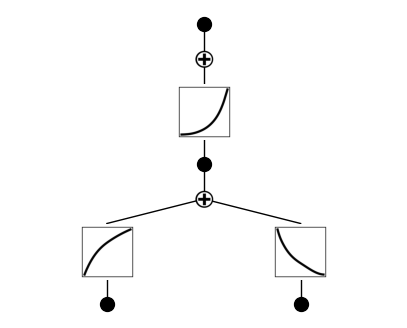

In [383]:
model.plot()

In [378]:
for module in model.modules():
    if isinstance(module, NexusKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[0.4370, 0.5630]],

        [[0.4260, 0.5740]]], device='cuda:0', grad_fn=<RoundBackward1>)
tensor([[[1.]]], device='cuda:0', grad_fn=<RoundBackward1>)


In [379]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data)

act_fun.0.coef tensor([[[ 1.1586e-02,  3.6656e-02, -5.5765e+00, -2.2665e+00, -1.6862e+00,
          -1.0635e+00, -2.7417e-01,  5.0491e-01]],

        [[ 4.0875e-03,  2.7029e-02,  3.7197e-02, -4.7931e-02,  3.5297e-03,
          -8.5240e-02, -1.9382e-02,  9.1586e-03]]], device='cuda:0')
act_fun.0.scale_base tensor([[-0.2050],
        [ 0.0115]], device='cuda:0')
act_fun.0.scale_sp tensor([[ 0.9426],
        [-0.0096]], device='cuda:0')
act_fun.0.logits tensor([[[0.5725, 0.5980]],

        [[0.7148, 0.7446]]], device='cuda:0')
act_fun.1.coef tensor([[[-0.2544,  0.1839,  0.6411,  1.0013,  1.4152,  0.7911,  0.6299,
           0.0116]]], device='cuda:0')
act_fun.1.scale_base tensor([[-0.1924]], device='cuda:0')
act_fun.1.scale_sp tensor([[1.6805]], device='cuda:0')
act_fun.1.logits tensor([[[0.2695]]], device='cuda:0')
symbolic_fun.0.affine tensor([[[0., 0., 0., 0.],
         [0., 0., 0., 0.]]], device='cuda:0')
symbolic_fun.1.affine tensor([[[0., 0., 0., 0.]]], device='cuda:0')


## **Test 3 :** $y = \frac{\frac{x_0}{x_1}}{\frac{x_2}{x_3}}$

In [273]:
end_range = 3.0
start_range = 1.0
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 4) + start_range

y = x[:, 0] / x[:, 1] / x[:, 2] / x[:, 3]

dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 4]), torch.Size([1000, 1]))

In [274]:
model = nexusKAN(width=[4, 2, 1], grid=5, k=3, seed=42, grid_range=[0.5, 4.0], device=device)

checkpoint directory created: ./model
saving model version 0.0


In [275]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=512, 
          epochs=1000)

--- Epoch [10/1000], Train Loss: 0.0022, Test Loss: 0.0068
--- Epoch [20/1000], Train Loss: 0.0026, Test Loss: 0.0029
--- Epoch [30/1000], Train Loss: 0.0009, Test Loss: 0.0013
--- Epoch [40/1000], Train Loss: 0.0007, Test Loss: 0.0007
--- Epoch [50/1000], Train Loss: 0.0003, Test Loss: 0.0003
--- Epoch [60/1000], Train Loss: 0.0001, Test Loss: 0.0001
--- Epoch [70/1000], Train Loss: 0.0001, Test Loss: 0.0001
--- Epoch [80/1000], Train Loss: 0.0000, Test Loss: 0.0001
--- Epoch [90/1000], Train Loss: 0.0000, Test Loss: 0.0000
--- Epoch [100/1000], Train Loss: 0.0000, Test Loss: 0.0000
--- Epoch [110/1000], Train Loss: 0.0000, Test Loss: 0.0000
--- Epoch [120/1000], Train Loss: 0.0000, Test Loss: 0.0000
--- Epoch [130/1000], Train Loss: 0.0000, Test Loss: 0.0000
--- Epoch [140/1000], Train Loss: 0.0000, Test Loss: 0.0000
--- Epoch [150/1000], Train Loss: 0.0000, Test Loss: 0.0000
--- Epoch [160/1000], Train Loss: 0.0000, Test Loss: 0.0000
--- Epoch [170/1000], Train Loss: 0.0000, Test Lo

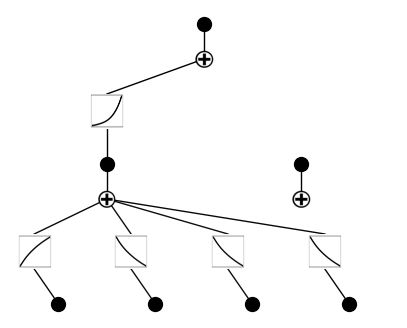

In [276]:
model.plot()

In [277]:
for module in model.modules():
    if isinstance(module, NexusKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[0.2360, 0.2020, 0.5610],
         [0.5260, 0.3490, 0.1250]],

        [[0.0420, 0.0480, 0.9100],
         [0.3430, 0.5300, 0.1280]],

        [[0.0390, 0.0480, 0.9130],
         [0.4000, 0.5370, 0.0630]],

        [[0.2250, 0.2320, 0.5430],
         [0.4550, 0.2850, 0.2600]]], device='cuda:0', grad_fn=<RoundBackward1>)
tensor([[[0.2730, 0.7270]],

        [[0.5320, 0.4680]]], device='cuda:0', grad_fn=<RoundBackward1>)


## $y = \frac{\frac{x_0}{x_1} + \frac{x_2}{x_3}}{\frac{x_4}{x_5} + \frac{x_6}{x_7}}$

In [41]:
end_range = 15.0
start_range = 5.0
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 8) + start_range

# x[:, 1] = 5.5
# x[:, 3] = 6.4
# x[:, 5] = 8.5
# x[:, 7] = 7.6

y = (x[:, 0] / x[:, 1] + x[:, 2] / x[:, 3]) / (x[:, 4] / x[:, 5] + x[:, 6] / x[:, 7])

dataset = {
    'train_input': x[:num_samples],
    'train_label': y[:num_samples].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 8]), torch.Size([1000, 1]))

checkpoint directory created: ./model
saving model version 0.0


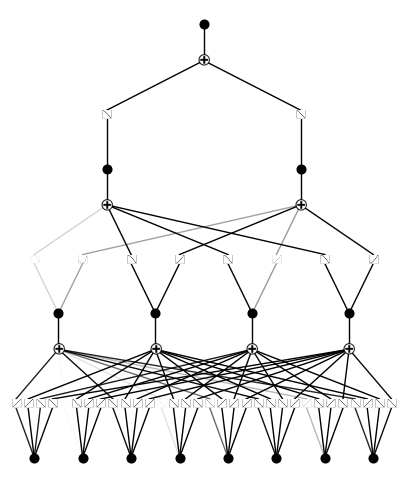

In [42]:
model = nexusKAN(width=[8, 4, 2, 1], grid=5, k=3, seed=42, 
                 grid_range=[3.0, 20.0],
                 device=device)
model(dataset['train_input'])
model.plot()

In [43]:
fit_model(model=model, 
          dataset=dataset,
          lr=0.1, 
          batch_size=32, 
          epochs=200)

--- Epoch [10/200], Train Loss: 0.0113, Test Loss: 0.0218
--- Epoch [20/200], Train Loss: 0.0145, Test Loss: 0.0090
--- Epoch [30/200], Train Loss: 0.0077, Test Loss: 0.0062
--- Epoch [40/200], Train Loss: 0.0061, Test Loss: 0.0074
--- Epoch [50/200], Train Loss: 0.0069, Test Loss: 0.0054
--- Epoch [60/200], Train Loss: 0.0049, Test Loss: 0.0065
--- Epoch [70/200], Train Loss: 0.0028, Test Loss: 0.0042
--- Epoch [80/200], Train Loss: 0.0125, Test Loss: 0.0065
--- Epoch [90/200], Train Loss: 0.0113, Test Loss: 0.0051
--- Epoch [100/200], Train Loss: 0.0104, Test Loss: 0.0052
--- Epoch [110/200], Train Loss: 0.0035, Test Loss: 0.0033
--- Epoch [120/200], Train Loss: 0.0031, Test Loss: 0.0026
--- Epoch [130/200], Train Loss: 0.0023, Test Loss: 0.0043
--- Epoch [140/200], Train Loss: 0.0108, Test Loss: 0.0030
--- Epoch [150/200], Train Loss: 0.0106, Test Loss: 0.0034
--- Epoch [160/200], Train Loss: 0.0120, Test Loss: 0.0034
--- Epoch [170/200], Train Loss: 0.0123, Test Loss: 0.0034
--- Ep

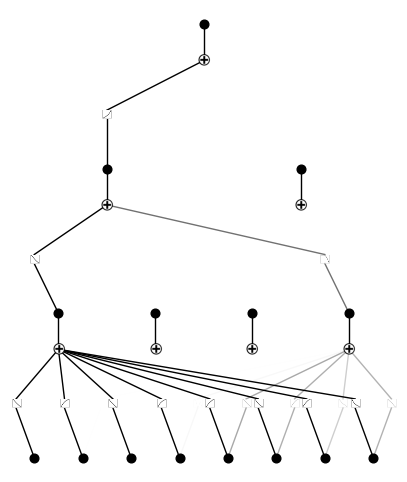

In [45]:
model.plot()

In [46]:
for module in model.modules():
    if isinstance(module, NexusKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[0.3020, 0.2610, 0.0990, 0.1450, 0.1940],
         [0.0000, 0.0000, 0.0830, 0.9170, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
         [0.0000, 1.0000, 0.0000, 0.0000, 0.0000]],

        [[0.4150, 0.1860, 0.0790, 0.1480, 0.1710],
         [1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
         [1.0000, 0.0000, 0.0000, 0.0000, 0.0000]],

        [[0.1170, 0.1700, 0.1760, 0.4170, 0.1210],
         [0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
         [1.0000, 0.0000, 0.0000, 0.0000, 0.0000]],

        [[0.2030, 0.0420, 0.0000, 0.5090, 0.2450],
         [0.0000, 0.0000, 0.0030, 0.0000, 0.9970],
         [0.1900, 0.6020, 0.1100, 0.0980, 0.0000],
         [0.0000, 0.0000, 1.0000, 0.0000, 0.0000]],

        [[0.0000, 0.7490, 0.0000, 0.0000, 0.2510],
         [0.0000, 1.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
         [0.0000, 0.000